# Forecast Diagnostics

Four quantile-level diagnostics, each shown as four panels (Baseline, CRPS-only control,
DFL single-price, DFL dual-price) side by side, sharing axes within a row where possible.
Retrained arms are seed-averaged (N=5, mean +/- std/error bars); baseline is a single fixed
checkpoint with no error bars, matching every other multi-seed comparison in this project.

1. **Asymmetry bar chart** -- hour-by-hour upper/lower quantile spread
   (`q_0.9 - q_0.5` vs. `q_0.5 - q_0.1`), a butterfly chart per forecaster.
2. **Reliability diagram** -- empirical coverage vs. nominal quantile level, four separate
   panels, 45-degree reference line.
3. **Quantile score plot** -- mean pinball loss per quantile level. Area-under-curve
   relationship to CRPS stated precisely below (a factor of 2, not 1 -- see that section).
4. **Bias plot** -- reused verbatim from `forecast_characteristics.ipynb` Section 10d (3
   panels: baseline overlaid as a reference line on each of control/single/dual, not its
   own 4th panel -- this one plot intentionally keeps the original 3-panel convention).

The first three diagnostics are forecaster-quantile-only properties -- no copula, no
dispatch solve needed, same cheap tier as `quantile_shift_analysis.ipynb`. Only the bias
plot (Section 4) needs the copula sampler's `mean_and_errors`.

## Setup

In [ ]:
from __future__ import annotations
import sys
import pickle
import numpy as np
import torch
import matplotlib.pyplot as plt
from pyprojroot import here

sys.path.insert(0, str(here() / "8_testing"))
from eval_raw import (
    load_test_windows, forecast_quantiles, fresh_baseline_model, dfl_model_from,
    FORECASTING_DIR, DFL_TRAIN_DIR, COPULA_DIR, QUANTILE_LEVELS, FrozenCopulaSampler,
)

SEEDS = [20240801, 20240802, 20240803, 20240804, 20240805]
DEFAULT_SEED = 20240801
FAMILY_BASE_ID = {
    "Baseline": None,   # special-cased -- loaded directly, not via load_dfl
    "Control": "crps_only_retrained",
    "DFL Single-price": "dfl_1stage_single-price",
    "DFL Dual-price": "dfl_1stage_dual-price",
}
FAMILY_ORDER = list(FAMILY_BASE_ID)
FAMILY_COLORS = {"Baseline": "C0", "Control": "grey", "DFL Single-price": "C6", "DFL Dual-price": "C3"}


def seed_variant(base_id, seed):
    return base_id if seed == DEFAULT_SEED else f"{base_id}_seed{seed}"


print("loading test windows...")
windows = load_test_windows()
n_days = len(windows.delivery_start)

baseline_ckpt = torch.load(FORECASTING_DIR / "baseline_forecaster_best.pt", weights_only=False, map_location="cpu")
sc = baseline_ckpt["scaler_stats"]
baseline_model = fresh_baseline_model(baseline_ckpt)


def load_dfl(forecaster_id):
    ck = torch.load(DFL_TRAIN_DIR / f"{forecaster_id}.pt", weights_only=False, map_location="cpu")
    return dfl_model_from(baseline_ckpt, ck)


idx10 = int(np.argmin(np.abs(QUANTILE_LEVELS - 0.10)))
idx50 = int(np.argmin(np.abs(QUANTILE_LEVELS - 0.50)))
idx90 = int(np.argmin(np.abs(QUANTILE_LEVELS - 0.90)))
print(f"n_test_days={n_days}  Q={len(QUANTILE_LEVELS)}  idx10={idx10} idx50={idx50} idx90={idx90}")

loading test windows...
[impute] 66 missing values across ['prosumption', 'solar_irrad', 'panel_temp', 'ambient_temp'] after reindex
[impute]   prosumption: 20 missing, longest run 11h   <-- LONG GAP (review)
[impute]   panel_temp: 46 missing, longest run 19h   <-- LONG GAP (review)


n_test_days=366  Q=19  idx10=1 idx50=9 idx90=17


### Shared quantile collection

One forecast pass per (family, seed) over the full test year, cached and reused by
Sections 1-3 below (all three read off the same raw (day, hour, quantile-level) array --
no need to re-run the forecaster three times).

In [ ]:
def collect_quantiles(model):
    """(n_days, 24, Q) forecast quantiles and (n_days, 24) realised, full test year."""
    q_all = np.empty((n_days, 24, len(QUANTILE_LEVELS)))
    y_all = np.empty((n_days, 24))
    for d in range(n_days):
        q_all[d] = forecast_quantiles(model, sc, windows.x_hist[d], windows.x_fut[d]).numpy()
        y_all[d] = np.asarray(windows.y[d], float)
    return q_all, y_all


CACHE = {}   # (family, seed) -> (q_all, y_all)
for family in FAMILY_ORDER:
    base_id = FAMILY_BASE_ID[family]
    seeds = [DEFAULT_SEED] if family == "Baseline" else SEEDS
    for seed in seeds:
        model = baseline_model if family == "Baseline" else load_dfl(seed_variant(base_id, seed))
        CACHE[(family, seed)] = collect_quantiles(model)
        print(f"  collected {family} seed={seed}", flush=True)
print(f"done -- {len(CACHE)} (family, seed) combinations cached")

  collected Baseline seed=20240801


  collected Control seed=20240801


  collected Control seed=20240802


  collected Control seed=20240803


  collected Control seed=20240804


...

  collected DFL Dual-price seed=20240802


  collected DFL Dual-price seed=20240803


  collected DFL Dual-price seed=20240804


  collected DFL Dual-price seed=20240805


done -- 16 (family, seed) combinations cached


## Section 1 -- Asymmetry bar chart (hour-by-hour)

Upper spread `(1/N) sum (q_0.9 - q_0.5)` and lower spread `(1/N) sum (q_0.5 - q_0.1)`,
averaged across every test day at each hour of the 24-hour horizon (N = n_test_days).
Plotted as a butterfly/diverging bar chart per forecaster: upper spread bars extend up
from a centred zero axis, lower spread bars extend down (i.e. the bar's length is the
lower spread, drawn as a negative value so the two halves are visually comparable).
Retrained arms show the N=5 seed mean bar with a +/-1 std error bar; baseline has no
error bar (single checkpoint).

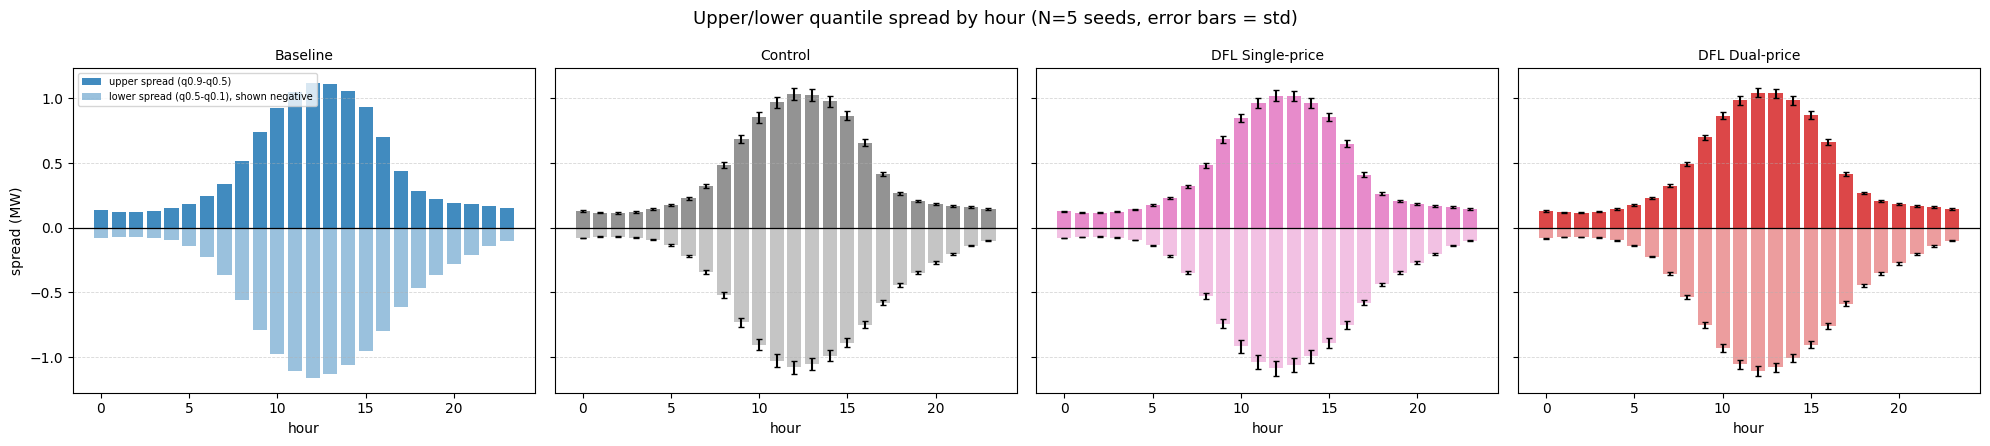

In [ ]:
def hourly_spreads(q_all):
    """(24,) upper spread, (24,) lower spread -- averaged over all test days at each hour."""
    upper = (q_all[:, :, idx90] - q_all[:, :, idx50]).mean(axis=0)
    lower = (q_all[:, :, idx50] - q_all[:, :, idx10]).mean(axis=0)
    return upper, lower


def family_spread_stats(family):
    seeds = [DEFAULT_SEED] if family == "Baseline" else SEEDS
    uppers, lowers = [], []
    for seed in seeds:
        u, l = hourly_spreads(CACHE[(family, seed)][0])
        uppers.append(u); lowers.append(l)
    uppers, lowers = np.array(uppers), np.array(lowers)
    return (uppers.mean(axis=0), uppers.std(axis=0) if len(seeds) > 1 else None,
            lowers.mean(axis=0), lowers.std(axis=0) if len(seeds) > 1 else None)


fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True)
h = np.arange(24)
for ax, family in zip(axes, FAMILY_ORDER):
    upper_mean, upper_std, lower_mean, lower_std = family_spread_stats(family)
    ax.bar(h, upper_mean, yerr=upper_std, color=FAMILY_COLORS[family], alpha=0.85,
           capsize=2, label="upper spread (q0.9-q0.5)")
    ax.bar(h, -lower_mean, yerr=lower_std, color=FAMILY_COLORS[family], alpha=0.45,
           capsize=2, label="lower spread (q0.5-q0.1), shown negative")
    ax.axhline(0, color="black", linewidth=0.9)
    ax.set_title(family, fontsize=10)
    ax.set_xlabel("hour")
    ax.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.5)
axes[0].set_ylabel("spread (MW)")
axes[0].legend(fontsize=7, loc="upper left")
fig.suptitle("Upper/lower quantile spread by hour (N=5 seeds, error bars = std)", fontsize=13)
fig.tight_layout()
plt.show()

## Section 2 -- Reliability diagram (calibration curve)

Empirical coverage at each of the 19 native quantile levels: the fraction of (test day,
hour) observations where realised prosumption falls at or below the forecaster's stated
quantile at that level, pooled across the full test year. A perfectly calibrated
forecaster's empirical coverage equals the nominal quantile level exactly (the 45-degree
line). Four separate panels (not overlaid), N=5 seed mean +/- std shaded band.

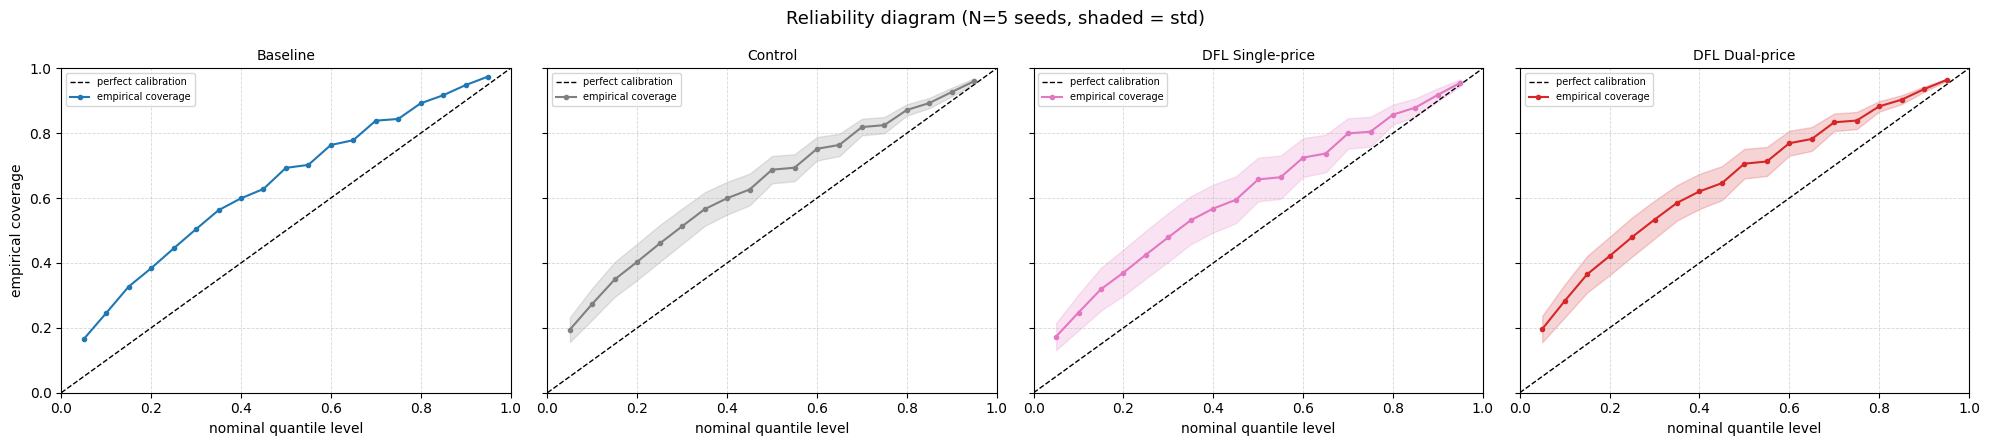

In [ ]:
def empirical_coverage(q_all, y_all):
    """(Q,) empirical coverage -- fraction of all (day, hour) observations <= each
    quantile level's forecast, pooled over the full test year."""
    y_flat = y_all.reshape(-1)                        # (n_days*24,)
    q_flat = q_all.reshape(-1, q_all.shape[-1])        # (n_days*24, Q)
    return (y_flat[:, None] <= q_flat).mean(axis=0)


def family_coverage_stats(family):
    seeds = [DEFAULT_SEED] if family == "Baseline" else SEEDS
    covs = [empirical_coverage(*CACHE[(family, seed)]) for seed in seeds]
    covs = np.array(covs)
    return covs.mean(axis=0), (covs.std(axis=0) if len(seeds) > 1 else None)


fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True, sharex=True)
diag = np.array([0.0, 1.0])
for ax, family in zip(axes, FAMILY_ORDER):
    cov_mean, cov_std = family_coverage_stats(family)
    ax.plot(diag, diag, "k--", linewidth=1, label="perfect calibration")
    ax.plot(QUANTILE_LEVELS, cov_mean, "-o", color=FAMILY_COLORS[family], markersize=3, label="empirical coverage")
    if cov_std is not None:
        ax.fill_between(QUANTILE_LEVELS, cov_mean - cov_std, cov_mean + cov_std,
                         color=FAMILY_COLORS[family], alpha=0.2)
    ax.set_title(family, fontsize=10)
    ax.set_xlabel("nominal quantile level")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.grid(linestyle="--", linewidth=0.6, alpha=0.5)
    ax.legend(fontsize=7, loc="upper left")
axes[0].set_ylabel("empirical coverage")
fig.suptitle("Reliability diagram (N=5 seeds, shaded = std)", fontsize=13)
fig.tight_layout()
plt.show()

## Section 3 -- Quantile score plot

Mean pinball loss $\rho_\tau$ at each of the 19 quantile levels, pooled over every (test
day, hour) observation. **Corrected area-under-curve relationship**: the standard
quantile-CRPS identity (the same one this project's own `crps_per_measurement` already
implements) is

$$\mathrm{CRPS} = 2 \int_0^1 \rho_\tau \, d\tau$$

so the area under the curve plotted here equals **half** of CRPS, not CRPS itself --
CRPS is twice the area under this curve (approximated the same way
`crps_per_measurement` does, as $2 \times$ the mean of $\rho_\tau$ over the 19 discrete
levels, not a continuous integral). Four separate panels, N=5 seed mean +/- std shaded.

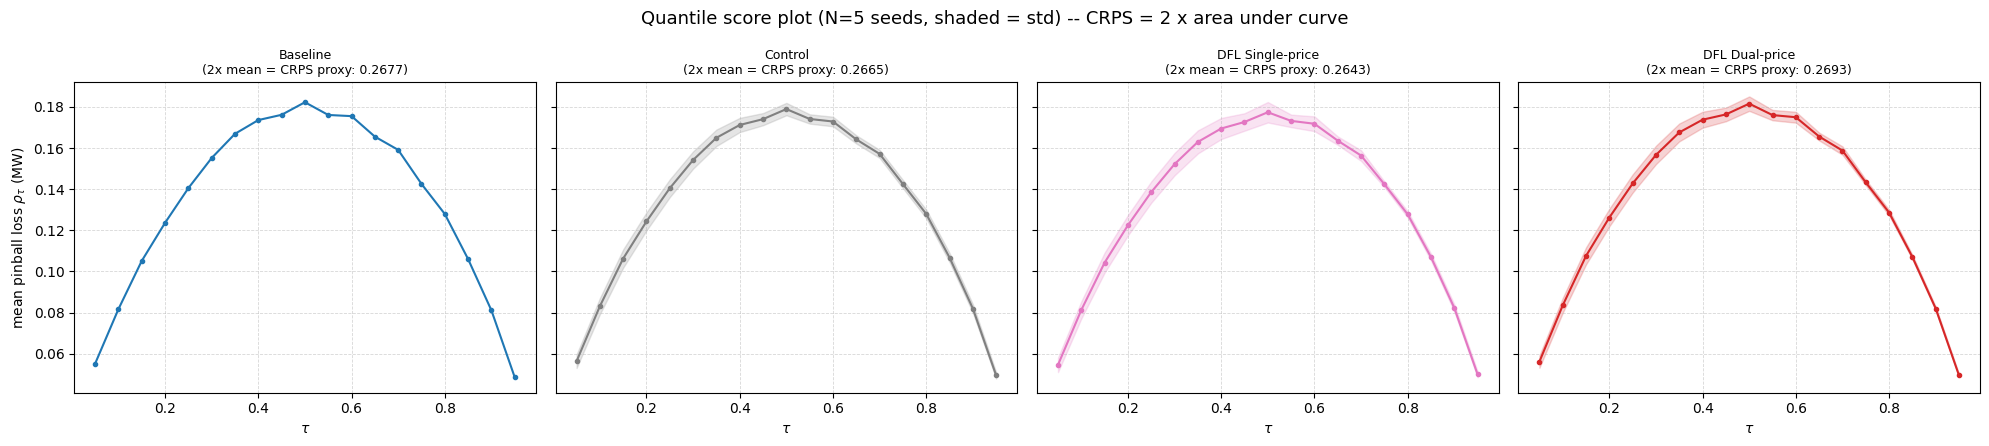

In [ ]:
def mean_pinball_per_level(q_all, y_all):
    """(Q,) mean pinball loss per quantile level, pooled over every (day, hour)
    observation -- same pinball formula as crps_per_measurement, WITHOUT the final
    x2 factor and WITHOUT averaging across levels (kept per-level for this plot)."""
    y_flat = y_all.reshape(-1)                        # (n_days*24,)
    q_flat = q_all.reshape(-1, q_all.shape[-1])        # (n_days*24, Q)
    e = y_flat[:, None] - q_flat
    tau = QUANTILE_LEVELS[None, :]
    pinball = np.maximum(tau * e, (tau - 1.0) * e)
    return pinball.mean(axis=0)


def family_pinball_stats(family):
    seeds = [DEFAULT_SEED] if family == "Baseline" else SEEDS
    vals = [mean_pinball_per_level(*CACHE[(family, seed)]) for seed in seeds]
    vals = np.array(vals)
    return vals.mean(axis=0), (vals.std(axis=0) if len(seeds) > 1 else None)


fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharey=True, sharex=True)
for ax, family in zip(axes, FAMILY_ORDER):
    rho_mean, rho_std = family_pinball_stats(family)
    ax.plot(QUANTILE_LEVELS, rho_mean, "-o", color=FAMILY_COLORS[family], markersize=3)
    if rho_std is not None:
        ax.fill_between(QUANTILE_LEVELS, rho_mean - rho_std, rho_mean + rho_std,
                         color=FAMILY_COLORS[family], alpha=0.2)
    implied_crps = 2 * rho_mean.mean()
    ax.set_title(f"{family}\n(2x mean = CRPS proxy: {implied_crps:.4f})", fontsize=9)
    ax.set_xlabel(r"$\tau$")
    ax.grid(linestyle="--", linewidth=0.6, alpha=0.5)
axes[0].set_ylabel(r"mean pinball loss $\rho_\tau$ (MW)")
fig.suptitle(r"Quantile score plot (N=5 seeds, shaded = std) -- CRPS = 2 x area under curve", fontsize=13)
fig.tight_layout()
plt.show()

## Section 4 -- Bias plot

Reused verbatim from `forecast_characteristics.ipynb` Section 10d (mean-signed bias by
hour): baseline shown as a shared reference line overlaid on each of the three retrained
arms' own panels, N=5 seed mean +/- std shaded -- the one diagnostic in this document that
intentionally keeps the original 3-panel layout rather than giving baseline its own 4th
panel, since that's how this exact figure already exists and there's no reason to
re-derive it differently here.

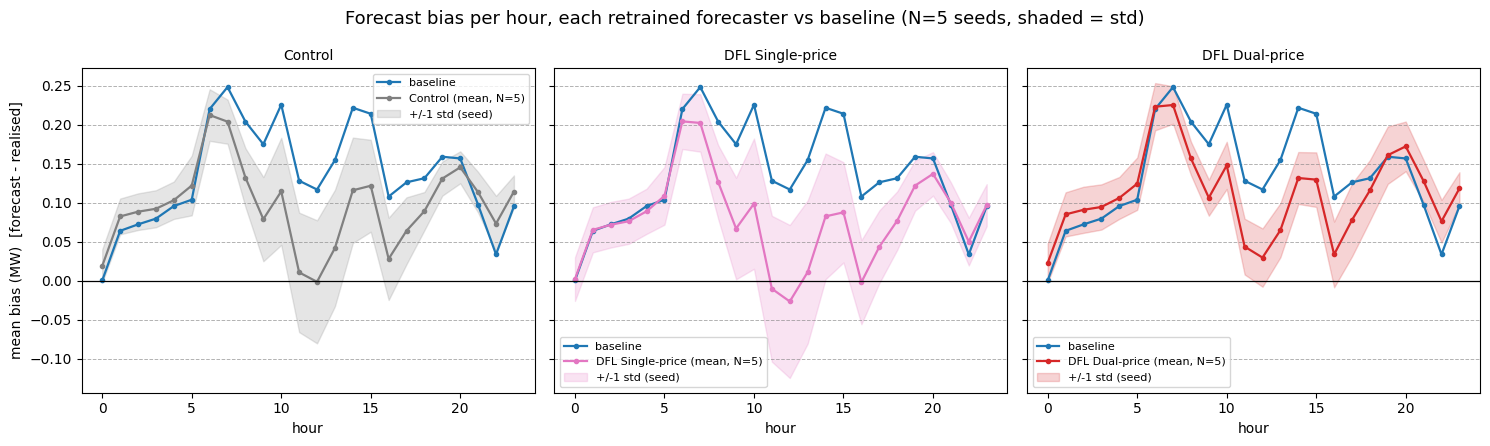

In [ ]:
cop_bundle = pickle.load(open(COPULA_DIR / "frozen_copula.pkl", "rb"))
sampler = FrozenCopulaSampler(cop_bundle["Z_corr"], cop_bundle["quantile_levels"])
ALL_DAYS = range(n_days)
comparison_colors = {"baseline": "C0", "Control": "grey", "DFL Single-price": "C6", "DFL Dual-price": "C3"}


def hourly_bias_own(model, day_indices):
    """Mean SIGNED error by hour-of-day: (mean - realised), per day then averaged --
    positive = over-predicts, negative = under-predicts."""
    errs = []
    for d in day_indices:
        q = forecast_quantiles(model, sc, windows.x_hist[d], windows.x_fut[d])
        mean, _ = sampler.mean_and_errors(q)
        mean = mean.detach().cpu().numpy()
        realised = np.asarray(windows.y[d], float)
        errs.append(mean - realised)
    return np.mean(errs, axis=0)


def metric_across_seeds(base_id):
    vals = np.array([hourly_bias_own(load_dfl(seed_variant(base_id, seed)), ALL_DAYS) for seed in SEEDS])
    return vals.mean(axis=0), vals.std(axis=0)


def plot_metric_row(baseline_series, panels, colors, ylabel, fig_title):
    h = np.arange(24)
    fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 4.5), sharey=True)
    for ax, (label, mean, std) in zip(axes, panels):
        ax.plot(h, baseline_series, "-o", color=colors["baseline"], markersize=3, label="baseline", linewidth=1.6)
        ax.plot(h, mean, "-o", color=colors[label], markersize=3, label=f"{label} (mean, N=5)", linewidth=1.6)
        ax.fill_between(h, mean - std, mean + std, color=colors[label], alpha=0.2, label="+/-1 std (seed)")
        ax.axhline(0, color="black", linewidth=0.9, zorder=2)
        ax.grid(axis="y", linestyle="--", linewidth=0.7, color="grey", alpha=0.6, zorder=0)
        ax.set_xlabel("hour")
        ax.set_title(label, fontsize=10)
        ax.legend(fontsize=8, loc="best")
    axes[0].set_ylabel(ylabel)
    fig.suptitle(fig_title, fontsize=13)
    fig.tight_layout()
    plt.show()


bias_base = hourly_bias_own(baseline_model, ALL_DAYS)
bias_crps_mean, bias_crps_std = metric_across_seeds("crps_only_retrained")
bias_single_mean, bias_single_std = metric_across_seeds("dfl_1stage_single-price")
bias_dual_mean, bias_dual_std = metric_across_seeds("dfl_1stage_dual-price")

plot_metric_row(
    bias_base,
    [("Control", bias_crps_mean, bias_crps_std),
     ("DFL Single-price Imbalance Market", bias_single_mean, bias_single_std),
     ("DFL Dual-price Imbalance Market", bias_dual_mean, bias_dual_std)],
    comparison_colors, ylabel="mean bias (MW)  [forecast - realised]",
    fig_title="Forecast bias per hour, retrained forecasters vs baseline (N=5 seeds, shaded = standard dev.)")